In [4]:
%pip install pandas numpy scikit-learn matplotlib seaborn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 804.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.0/8.1 MB 42.9 MB/s eta 0:00:01
   ------------------------------- -------- 6.4/8.1 MB 67.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 73.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 57.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/309.1 kB ? eta -:--:--
   --------------------------------------- 309.1/309.1 kB 18.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/36.6 MB 97.5 MB/s eta 0:00:01
   -------- ---


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df, y = load_wine(as_frame=True, return_X_y=True)
df['quality'] = y
df.info()
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  quality         

In [13]:
# 1. 데이터셋에 포함된 와인 총 샘플 수 구하기
# 2. 데이터셋에 포함된 특징 수 구하기
sample_count, feature_count = df.shape
sample_count, feature_count

(178, 14)

In [14]:
# 3. quality의 종류
class_count = df['quality'].nunique()
class_count

3

In [16]:
# 4. quality 별 샘플 개수 구하기
class_distribution = df['quality'].value_counts().sort_index()
class_distribution

quality
0    59
1    71
2    48
Name: count, dtype: int64

In [18]:
# 5. Alcohol의 평균값 가장 높은 클래스 구하기
top_alcohol_class = df.groupby('quality')['alcohol'].mean().idxmax()
top_alcohol_class

np.int64(0)

In [22]:
# color intensity가 10 이상인 샘플의 비율
filtered_df = df['color_intensity'] >= 10
high_color_samples = df[filtered_df]
high_color_samples.describe()

high_color_ratio = len(high_color_samples) / len(df) * 100
high_color_ratio

3.932584269662921

In [26]:
# 10. Proline 분포에서 가장 높은 피크를 가지는 클래스 번호 구하기
bins = 20 # 각 테이터를 20개 단위로 끊는다.
global_min, global_max = df['proline'].min(), df['proline'].max()
peak_by_class = {}
for cls in df['quality'].unique():
    counts, _ = np.histogram(df.loc[df['quality'] == cls, 'proline'], bins=bins, range=(global_min, global_max))
    peak_by_class[int(cls)] = counts.max()

peak_by_class
max(peak_by_class, key=peak_by_class.get)
max_cls = -1
max_val = -1
for key, value in peak_by_class.items():
    if max_val < value:
        max_cls = key
        max_val = value
max_cls

1

In [32]:
# 12. Alcohol과 상관관계가 가장 높은 특성 구하기
alcohol_correlations = df.corr()['alcohol'].abs().sort_values(ascending=False)
alcohol_correlations.index[1]

'proline'

In [36]:
df.corr()['quality'].abs().sort_values(ascending=False)

quality                         1.000000
flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
alcalinity_of_ash               0.517859
proanthocyanins                 0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                         0.328222
color_intensity                 0.265668
magnesium                       0.209179
ash                             0.049643
Name: quality, dtype: float64

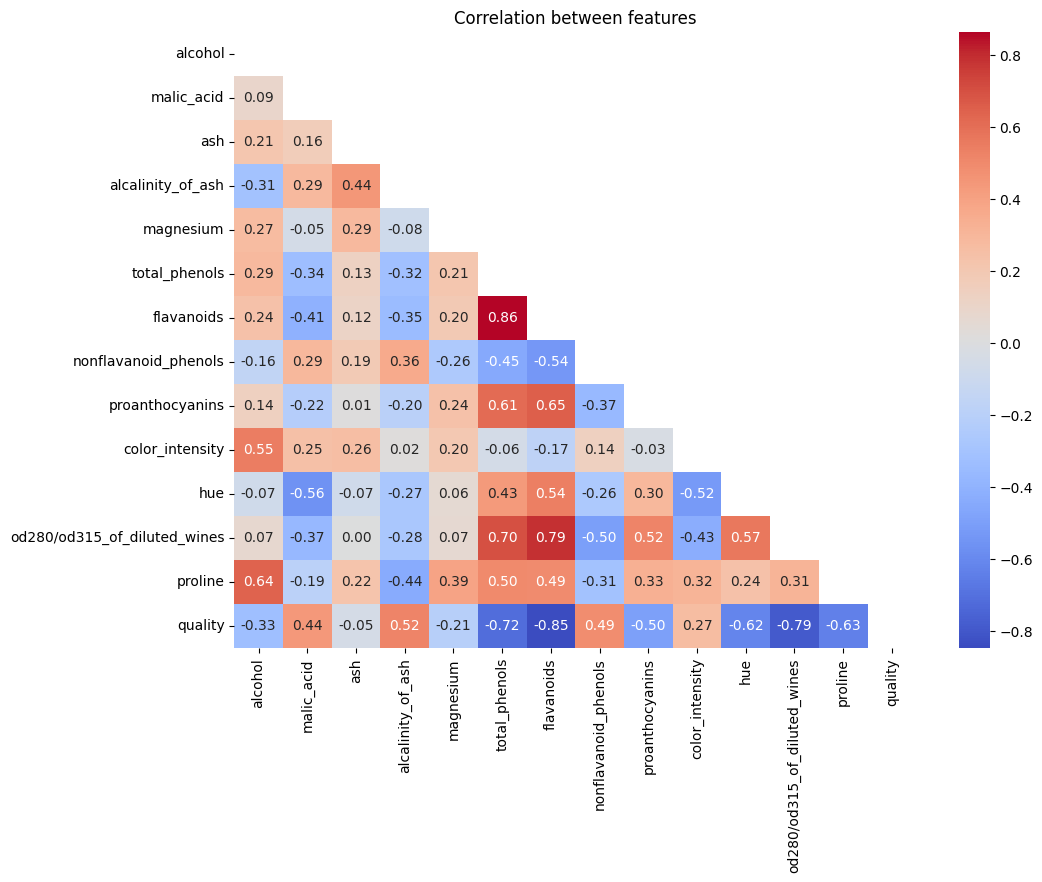

In [40]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(11, 8))
n = len(corr)
mask = np.triu(np.ones((n, n)))

sns.heatmap(data=corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask)
ax.grid(False)
ax.set_title('Correlation between features')
ax.set_facecolor("white")
plt.show()

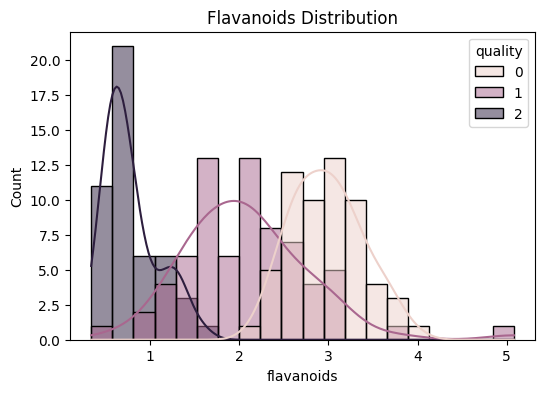

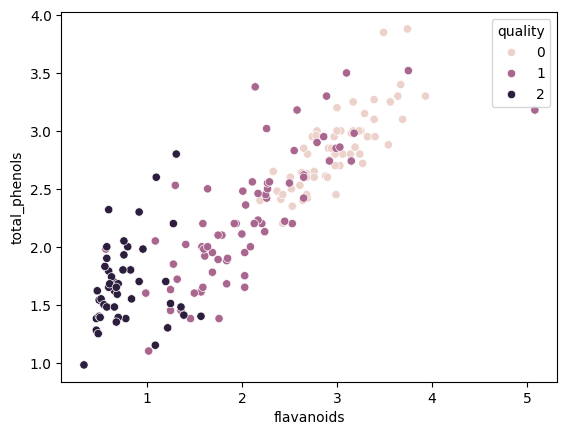

Index(['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols',
       'proline', 'hue'],
      dtype='str')


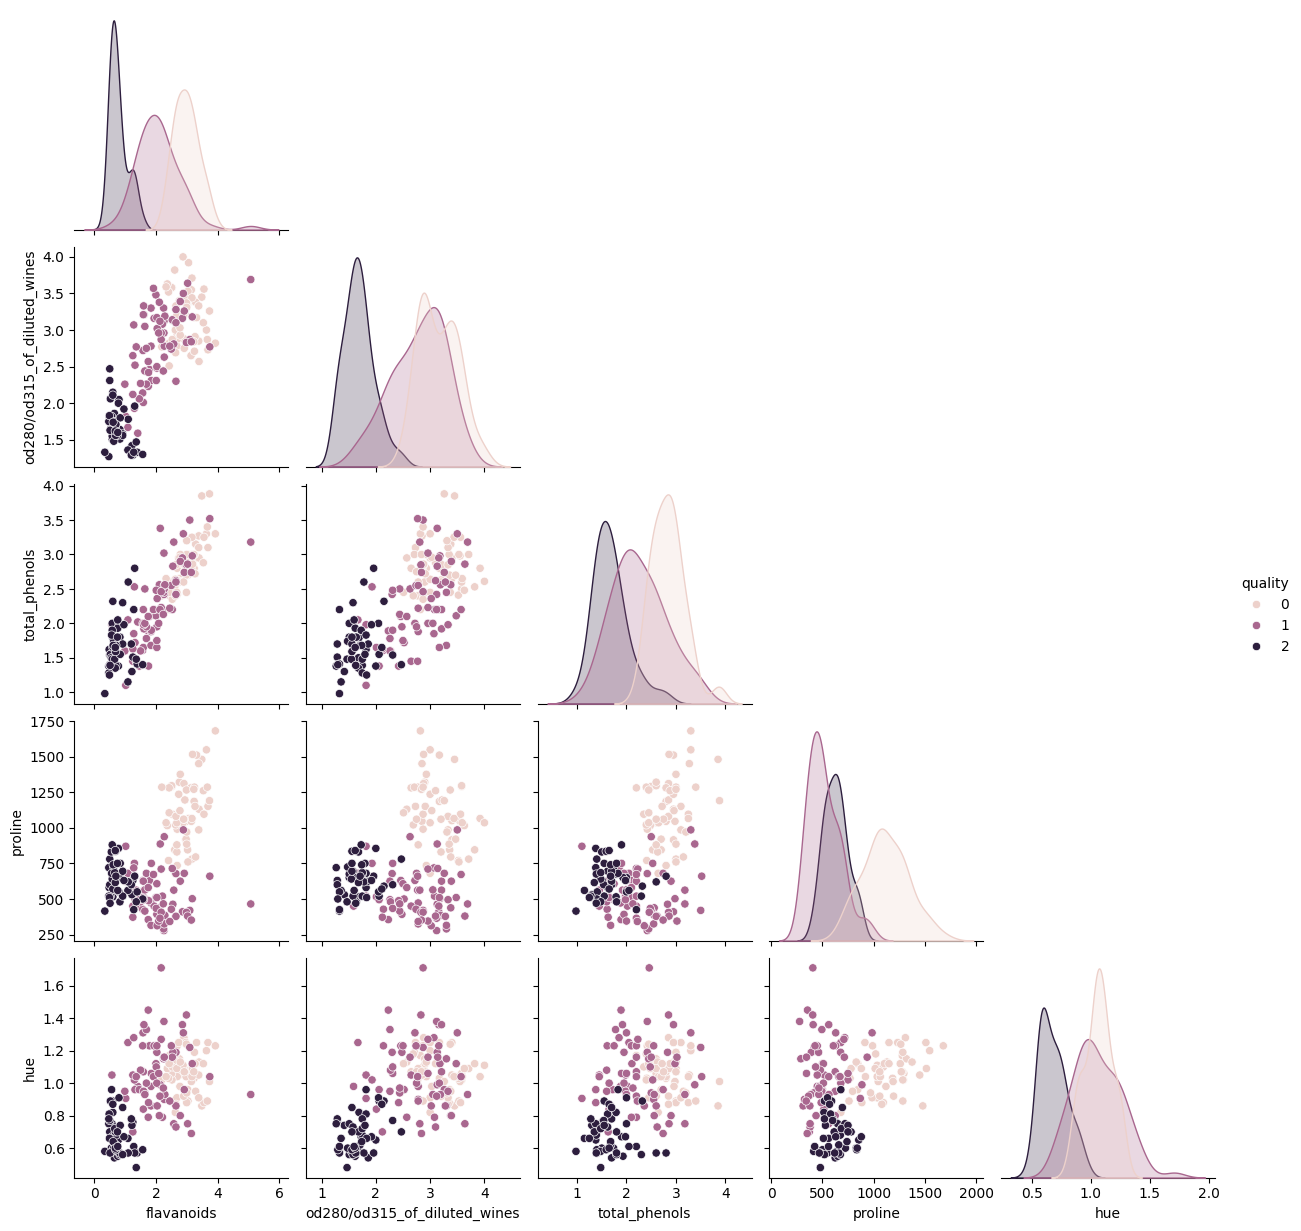

In [41]:

# Flavanoid 분포
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='flavanoids', hue='quality', bins=20, kde=True)
plt.title('Flavanoids Distribution')
plt.show()

# 산점도 그리기
sns.scatterplot(data=df, x='flavanoids', y='total_phenols', hue='quality')
plt.show()

# 높은 상관관계의 특성 5개를 pairplot으로 시각화

# 1. 상관관계가 높은 특성 5개
corr_with_quality = corr['quality'].abs().sort_values(ascending=False)
top_features = corr_with_quality.index[1:6]  # quality 제외, 상위 5개
print(top_features)

plot_df = df[top_features.tolist() + ["quality"]]
sns.pairplot(data=plot_df, hue="quality", corner=True)
plt.show() 

In [43]:
np.random.seed(42)

In [49]:
# 결측치 생성
df_missing = df.copy()
missing_idx = np.random.choice(df_missing.index, size=10, replace=False)
df_missing.loc[missing_idx, 'flavanoids'] = np.nan

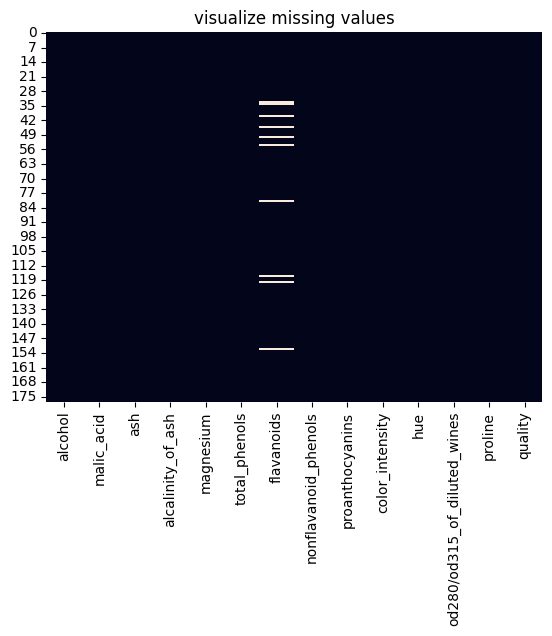

In [50]:
# heatmap으로 결측치 확인
sns.heatmap(df_missing.isnull(), cbar=False)
plt.title('visualize missing values')
plt.show()

In [51]:
# 이상치 생성
outlier_idx = np.random.choice(df_missing.index, size=5, replace=False)
df_missing.loc[outlier_idx, 'alcohol'] = df_missing['alcohol'].mean() * 5

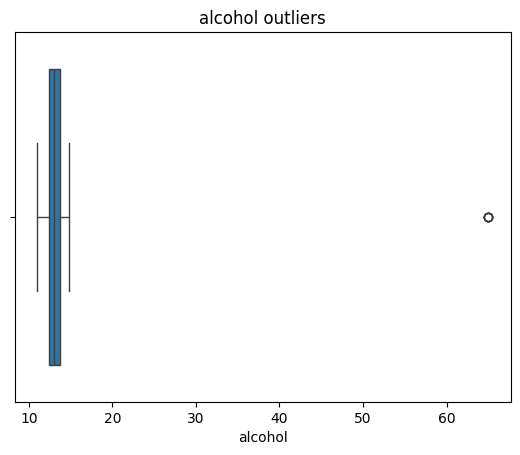

In [54]:
def detect_outliers_iqr(data, column):
    # data = df
    # column = 'alcohol'
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

outliers_alcohol = detect_outliers_iqr(df_missing, 'alcohol')
outliers_alcohol

# boxplot으로 이상치 확인
sns.boxplot(x=df_missing['alcohol'])
plt.title('alcohol outliers')
plt.show()

In [55]:
# 결측치는 평균값으로 대체
df_filled = df_missing.fillna(df_missing.mean(numeric_only=True))
print(df_filled.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
quality                         0
dtype: int64


In [57]:
# 이상치 처리
# 1. 이상치를 제거
df_no_outliers = df_filled[~df_filled.index.isin(outliers_alcohol.index)]
outliers_alcohol = detect_outliers_iqr(df_no_outliers, 'alcohol')
outliers_alcohol

# 2. 평균값으로 대체
mean_alcohol = df_filled['alcohol'].mean()
df_filled.loc[outliers_alcohol.index, 'alcohol'] = mean_alcohol
outliers_alcohol = detect_outliers_iqr(df_filled, 'alcohol')
outliers_alcohol

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,quality
19,65.00309,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.960,3.36,845.0,0
39,65.00309,3.99,2.51,13.2,128.0,3.00,3.04,0.20,2.08,5.10,0.890,3.53,760.0,0
70,65.00309,1.61,2.21,20.4,103.0,1.10,1.02,0.37,1.46,3.05,0.906,1.82,870.0,1
89,65.00309,1.33,2.30,23.6,70.0,2.20,1.59,0.42,1.38,1.74,1.070,3.21,625.0,1
121,65.00309,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.930,3.69,465.0,1
